# Disaster Tweet Model Results

This notebook visualizes saved training results for the baseline TF-IDF model and any transformer models with metric JSON files in `models/`. It focuses on validation metrics, confusion matrices, and stress-test misses.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR

WindowsPath('c:/Users/developer/projects/aipi540-disaster-tweets/models')

## Load Metrics

In [13]:
def load_json(path):
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


metric_records = []

baseline_path = MODELS_DIR / "baseline_metrics.json"
if baseline_path.exists():
    metrics = load_json(baseline_path)
    metric_records.append(
        {
            "display_name": "TF-IDF + Logistic Regression",
            "metrics_path": baseline_path,
            "metrics": metrics,
        }
    )

# New per-model metric files.
for path in sorted(MODELS_DIR.glob("transformer_metrics_*.json")):
    metrics = load_json(path)
    metric_records.append(
        {
            "display_name": metrics.get("model", path.stem.replace("transformer_metrics_", "")),
            "metrics_path": path,
            "metrics": metrics,
        }
    )

print(f"Loaded {len(metric_records)} metric files")
for record in metric_records:
    print(f"- {record['display_name']}: {record['metrics_path'].relative_to(PROJECT_ROOT)}")

Loaded 3 metric files
- TF-IDF + Logistic Regression: models\baseline_metrics.json
- cardiffnlp/twitter-roberta-base: models\transformer_metrics_cardiffnlp-twitter-roberta-base.json
- distilbert-base-uncased: models\transformer_metrics_distilbert-base-uncased.json


## Summary Table

In [4]:
summary_rows = []
for record in metric_records:
    metrics = record["metrics"]
    summary_rows.append(
        {
            "model": record["display_name"],
            "accuracy": metrics.get("accuracy"),
            "f1": metrics.get("f1"),
            "precision_disaster": metrics.get("precision_disaster"),
            "recall_disaster": metrics.get("recall_disaster"),
            "stress_accuracy": metrics.get("stress_accuracy"),
            "decision_threshold": metrics.get("decision_threshold", 0.5),
            "class_weighted_loss": metrics.get("class_weighted_loss", False),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values("recall_disaster", ascending=False)

,model,accuracy,f1,precision_disaster,recall_disaster,stress_accuracy,decision_threshold,class_weighted_loss
1,cardiffnlp/twitter-roberta-base,0.852265,0.821570,0.853377,0.792049,1.000000,0.75,True
0,TF-IDF + Logistic Regression,0.809055,0.779043,0.774924,0.783206,0.750000,0.50,False
2,distilbert-base-uncased,0.852265,0.817518,0.870466,0.770642,0.916667,0.49,True


## Metric Comparison

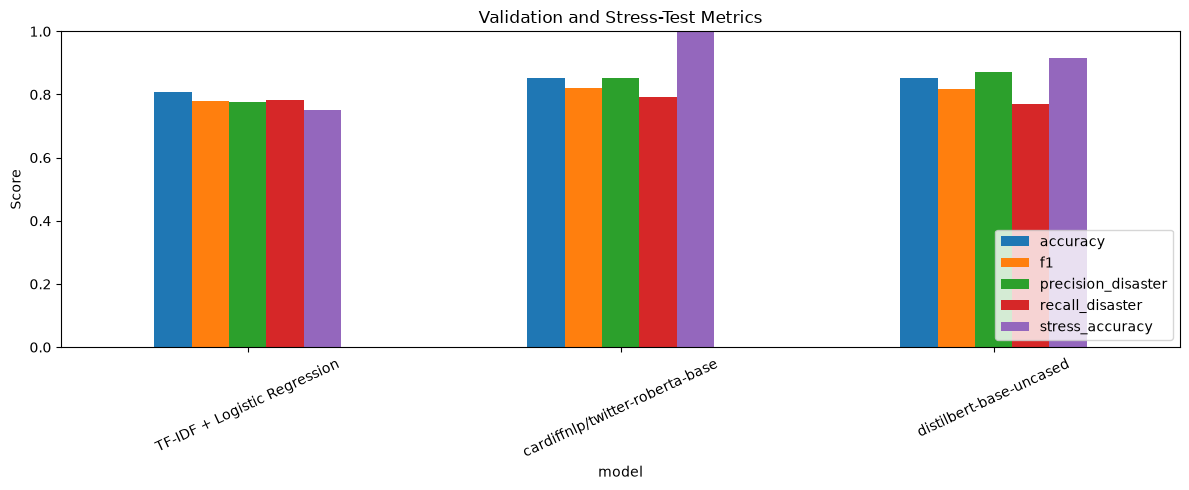

In [5]:
plot_df = summary_df.set_index("model")[["accuracy", "f1", "precision_disaster", "recall_disaster", "stress_accuracy"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5), ylim=(0, 1), rot=25)
ax.set_title("Validation and Stress-Test Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Confusion Matrices

Matrix layout is `[[TN, FP], [FN, TP]]`, where false negatives are missed real disasters.

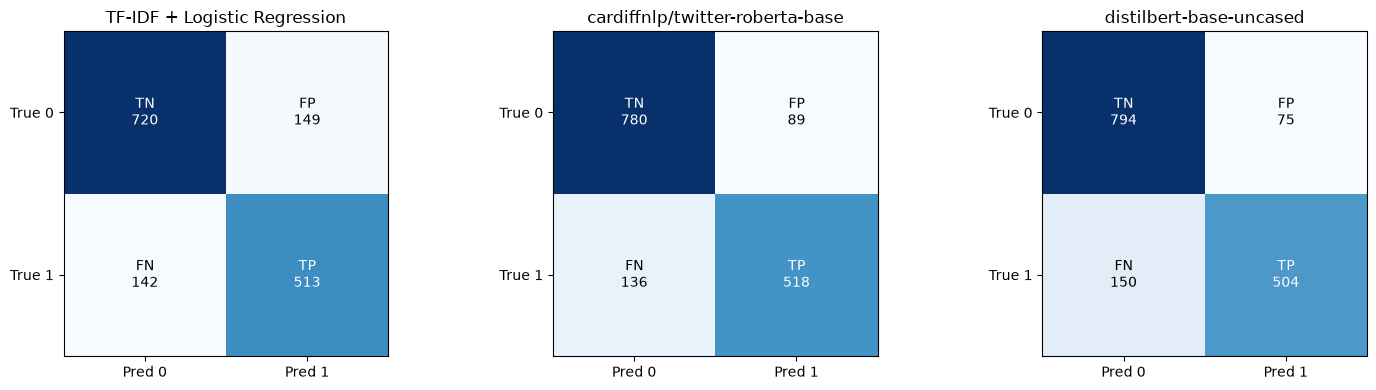

In [6]:
def plot_confusion_matrix(ax, matrix, title):
    labels = [["TN", "FP"], ["FN", "TP"]]
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], ["True 0", "True 1"])

    max_value = max(max(row) for row in matrix)
    for row_idx, row in enumerate(matrix):
        for col_idx, value in enumerate(row):
            text_color = "white" if value > max_value / 2 else "black"
            ax.text(col_idx, row_idx, f"{labels[row_idx][col_idx]}\n{value}", ha="center", va="center", color=text_color)
    return image


fig, axes = plt.subplots(1, len(metric_records), figsize=(5 * len(metric_records), 4))
if len(metric_records) == 1:
    axes = [axes]

for ax, record in zip(axes, metric_records):
    matrix = record["metrics"].get("confusion_matrix")
    plot_confusion_matrix(ax, matrix, record["display_name"])

plt.tight_layout()
plt.show()

## False Negatives vs False Positives

For the emergency-response framing, false negatives are especially important because they are missed real disasters.

In [7]:
error_rows = []
for record in metric_records:
    matrix = record["metrics"].get("confusion_matrix")
    if not matrix:
        continue
    error_rows.append(
        {
            "model": record["display_name"],
            "false_positives": matrix[0][1],
            "false_negatives": matrix[1][0],
            "true_positives": matrix[1][1],
            "true_negatives": matrix[0][0],
        }
    )

error_df = pd.DataFrame(error_rows)
error_df

,model,false_positives,false_negatives,true_positives,true_negatives
0,TF-IDF + Logistic Regression,149,142,513,720
1,cardiffnlp/twitter-roberta-base,89,136,518,780
2,distilbert-base-uncased,75,150,504,794


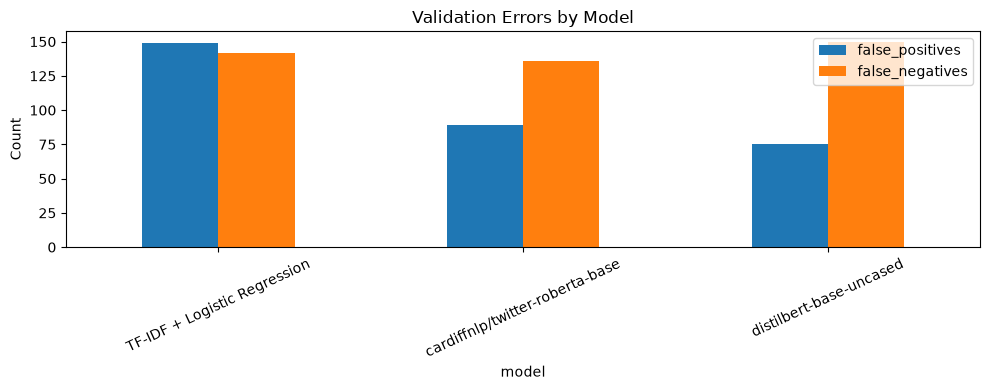

In [8]:
ax = error_df.set_index("model")[["false_positives", "false_negatives"]].plot(kind="bar", figsize=(10, 4), rot=25)
ax.set_title("Validation Errors by Model")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Stress-Test Results and Misses

In [9]:
stress_rows = []
for record in metric_records:
    for row in record["metrics"].get("stress_rows", []):
        stress_rows.append(
            {
                "model": record["display_name"],
                "category": row["category"],
                "target": row["target"],
                "prediction": row["prediction"],
                "correct": row["correct"],
                "text": row["text"],
            }
        )

stress_df = pd.DataFrame(stress_rows)
stress_df

,model,category,target,prediction,correct,text
0,TF-IDF + Logistic Regression,metaphor,0,0,True,This group project is a disaster and my inbox ...
1,TF-IDF + Logistic Regression,sarcasm,0,0,True,Forgot coffee this morning. Truly a national e...
2,TF-IDF + Logistic Regression,slang,1,1,True,yo the creek overflowed and water is in people...
3,TF-IDF + Logistic Regression,hashtag,1,1,True,"#wildfire smoke moving fast near Santa Rosa, e..."
4,TF-IDF + Logistic Regression,all_caps,1,1,True,TORNADO WARNING TAKE SHELTER NOW IN BASEMENT O...
5,TF-IDF + Logistic Regression,emoji,0,0,True,my haircut is a disaster 😭😭😭
6,TF-IDF + Logistic Regression,location,1,1,True,I-95 near exit 12 blocked after multi-car cras...
7,TF-IDF + Logistic Regression,ambiguous,0,0,True,The concert crowd was a riot last night.
8,TF-IDF + Logistic Regression,metaphor,0,1,False,This party was fire and the crowd exploded whe...
9,TF-IDF + Logistic Regression,metaphor,0,1,False,California dreaming is on fire today.


In [10]:
stress_summary = (
    stress_df.groupby(["model", "category"])["correct"]
    .agg(total="count", correct="sum")
    .reset_index()
)
stress_summary["accuracy"] = stress_summary["correct"] / stress_summary["total"]
stress_summary.sort_values(["model", "accuracy", "category"])

,model,category,total,correct,accuracy
5,TF-IDF + Logistic Regression,metaphor,3,1,0.333333
8,TF-IDF + Logistic Regression,slang,2,1,0.500000
0,TF-IDF + Logistic Regression,all_caps,1,1,1.000000
1,TF-IDF + Logistic Regression,ambiguous,1,1,1.000000
2,TF-IDF + Logistic Regression,emoji,1,1,1.000000
3,TF-IDF + Logistic Regression,hashtag,1,1,1.000000
4,TF-IDF + Logistic Regression,location,1,1,1.000000
6,TF-IDF + Logistic Regression,real_report,1,1,1.000000
7,TF-IDF + Logistic Regression,sarcasm,1,1,1.000000
9,cardiffnlp/twitter-roberta-base,all_caps,1,1,1.000000


In [11]:
stress_misses = stress_df[~stress_df["correct"]].copy()
stress_misses.sort_values(["model", "category", "text"])

,model,category,target,prediction,correct,text
9,TF-IDF + Logistic Regression,metaphor,0,1,False,California dreaming is on fire today.
8,TF-IDF + Logistic Regression,metaphor,0,1,False,This party was fire and the crowd exploded whe...
10,TF-IDF + Logistic Regression,slang,0,1,False,I am dead after that workout.
33,distilbert-base-uncased,metaphor,0,1,False,California dreaming is on fire today.


## Takeaways

In [12]:
best_recall = summary_df.sort_values("recall_disaster", ascending=False).iloc[0]
best_f1 = summary_df.sort_values("f1", ascending=False).iloc[0]

print(f"Best disaster recall: {best_recall['model']} ({best_recall['recall_disaster']:.3f})")
print(f"Best F1: {best_f1['model']} ({best_f1['f1']:.3f})")

if not stress_misses.empty:
    print("\nStress-test misses show where the models still confuse literal disaster language with figurative or ambiguous phrasing.")
else:
    print("\nNo stress-test misses found in the saved metric files.")

Best disaster recall: cardiffnlp/twitter-roberta-base (0.792)
Best F1: cardiffnlp/twitter-roberta-base (0.822)

Stress-test misses show where the models still confuse literal disaster language with figurative or ambiguous phrasing.
